# AirPulse AI — Urban Air Exposure & Sensor Intelligence
### AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026

**Goal:** Turn hourly air-quality sensor data into an analytical decision-support prototype that answers:
1. When do pollution patterns intensify?
2. Which environmental/sensor variables are most associated with NO₂?
3. Can machine learning predict NO₂ from available measurements?
4. Can anomalous observations be flagged before they distort decisions?

**Originality:** AirPulse combines **time-aware analytics + relative exposure-pressure indexing + supervised ML + unsupervised anomaly detection + model explainability** instead of stopping at a standard EDA or one regression model.

> The pressure index is a relative analytical indicator, **not a medical or regulatory air-quality classification**.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import io
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")


## 1. Dataset acquisition

The project uses the **UCI Air Quality** dataset. It contains 9,358 hourly observations from a gas multisensor device deployed at road level in an Italian city, with pollutant reference measurements and environmental variables. Missing values are represented by `-200`.

The notebook downloads the CSV directly from the official UCI repository and parses its semicolon-separated, comma-decimal format.


In [2]:
# Download directly from the official UCI Machine Learning Repository
# This avoids package/version differences in dataset import helpers.

UCI_URL = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"

with urllib.request.urlopen(UCI_URL, timeout=60) as response:
    zip_bytes = response.read()

with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
    csv_name = next(name for name in z.namelist() if name.lower().endswith("airqualityuci.csv"))
    with z.open(csv_name) as f:
        df = pd.read_csv(
            f,
            sep=";",
            decimal=",",
            na_values=[-200],
            usecols=range(15)
        )

# Remove completely empty rows sometimes present at the end of the source file.
df = df.dropna(how="all").copy()

print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Raw shape: (9357, 15)
Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## 2. Data cleaning and preprocessing

`-200` is converted to missing data. We create a proper timestamp, sort chronologically, interpolate short numeric gaps, and fill only residual gaps. This prevents missing markers from being interpreted as real pollution readings.


In [3]:
# Convert the UCI missing-value marker to NaN and build a reliable datetime index.
# The UCI file uses DD/MM/YYYY dates and HH.MM.SS times.

df = df.replace(-200, np.nan)

df["timestamp"] = pd.to_datetime(
    df["Date"].astype(str).str.strip() + " " +
    df["Time"].astype(str).str.strip().str.replace(".", ":", regex=False),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# Drop malformed/blank timestamp rows before using time-based interpolation.
df = df.dropna(subset=["timestamp"]).copy()
df = df.drop(columns=["Date", "Time"])

# Convert all measurements to numeric.
for col in df.columns:
    if col != "timestamp":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("timestamp").set_index("timestamp")

# Time interpolation is now safe because the datetime index contains no NaT values.
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].interpolate(method="time", limit=6)
df[numeric_cols] = df[numeric_cols].ffill().bfill()

print("Clean shape:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))
display(df.describe().T.round(2))


Clean shape: (9357, 13)
Remaining missing values: 0


,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,2.09,1.46,0.10,1.00,1.71,2.80,11.90
PT08.S1(CO),9357.0,1102.76,218.99,647.00,938.00,1064.00,1238.00,2040.00
NMHC(GT),9357.0,270.57,73.32,7.00,275.00,275.00,275.00,1189.00
C6H6(GT),9357.0,10.19,7.55,0.10,4.50,8.30,14.00,63.70
PT08.S2(NMHC),9357.0,942.49,269.11,383.00,737.00,911.00,1118.00,2214.00
NOx(GT),9357.0,240.44,205.07,2.00,96.00,174.00,318.00,1479.00
PT08.S3(NOx),9357.0,833.12,255.42,322.00,655.00,807.00,966.00,2683.00
NO2(GT),9357.0,109.25,46.96,2.00,75.28,103.00,137.00,340.00
PT08.S4(NO2),9357.0,1452.69,346.37,551.00,1228.00,1459.00,1674.00,2775.00
PT08.S5(O3),9357.0,1030.93,408.32,221.00,728.38,964.00,1287.00,2523.00


## 3. Feature engineering

Calendar features capture recurring temporal patterns. We also build a relative **Exposure Pressure Index (EPI)** using percentile ranks of available pollutant measurements. This index is intended only for comparing periods within this dataset.


In [4]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

pollutants = [c for c in ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"] if c in df.columns]
percentile_parts = [df[c].rank(pct=True) for c in pollutants]
df["exposure_pressure_index"] = pd.concat(percentile_parts, axis=1).mean(axis=1) * 100
df["pressure_band"] = pd.cut(
    df["exposure_pressure_index"],
    bins=[-np.inf, 25, 50, 75, np.inf],
    labels=["Low", "Moderate", "High", "Very High"]
)
display(df[["exposure_pressure_index", "pressure_band"]].head())


,exposure_pressure_index,pressure_band
timestamp,,
2004-03-10 18:00:00,61.301699,High
2004-03-10 19:00:00,45.758523,Moderate
2004-03-10 20:00:00,53.824677,High
2004-03-10 21:00:00,58.639254,High
2004-03-10 22:00:00,45.914823,Moderate


## 4. Exploratory Data Analysis

We examine hourly and monthly NO₂ patterns plus correlations among pollutants, sensors, and weather variables.


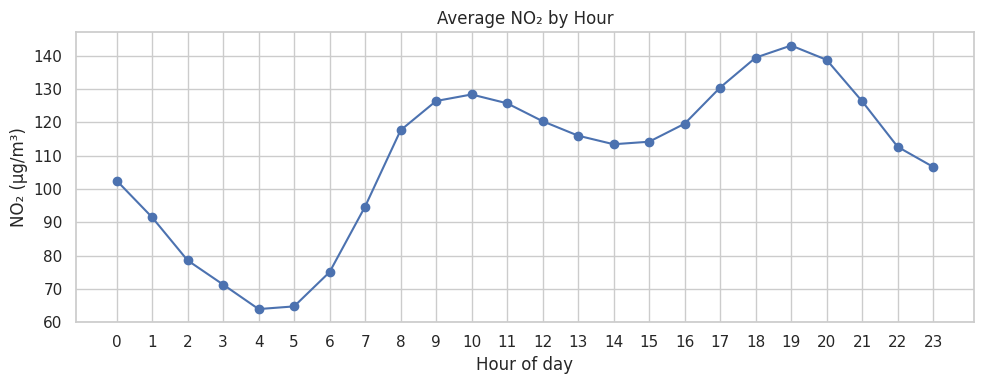

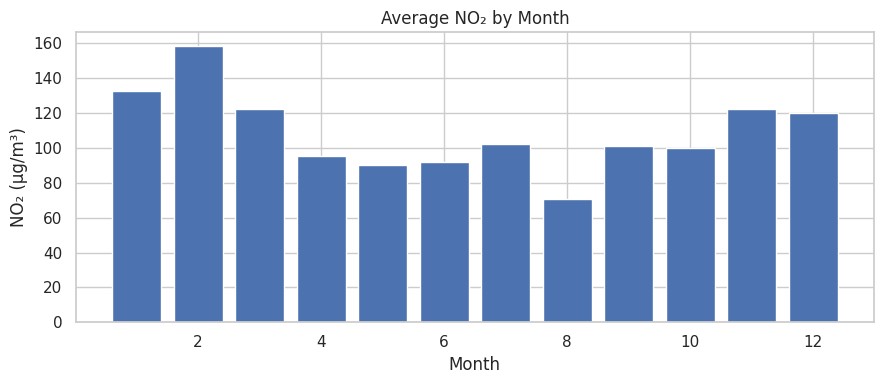

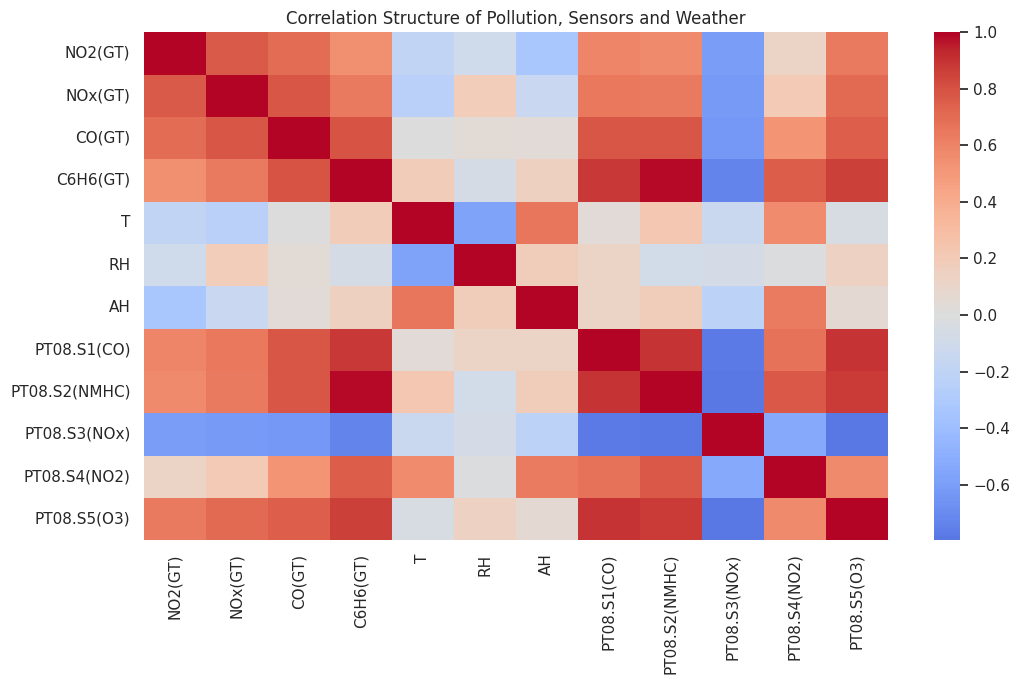

In [5]:
hourly = df.groupby("hour")["NO2(GT)"].mean()
plt.figure(figsize=(10,4))
plt.plot(hourly.index, hourly.values, marker="o")
plt.title("Average NO₂ by Hour")
plt.xlabel("Hour of day")
plt.ylabel("NO₂ (µg/m³)")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

monthly = df.groupby("month")["NO2(GT)"].mean()
plt.figure(figsize=(9,4))
plt.bar(monthly.index, monthly.values)
plt.title("Average NO₂ by Month")
plt.xlabel("Month")
plt.ylabel("NO₂ (µg/m³)")
plt.tight_layout()
plt.show()

corr_cols = [c for c in ["NO2(GT)", "NOx(GT)", "CO(GT)", "C6H6(GT)", "T", "RH", "AH",
                         "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"] if c in df.columns]
plt.figure(figsize=(11,7))
sns.heatmap(df[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Structure of Pollution, Sensors and Weather")
plt.tight_layout()
plt.show()


## 5. High-pressure period intelligence

The table below surfaces periods with the highest relative Exposure Pressure Index for operational inspection or dashboarding.


In [6]:
top_periods = (
    df.reset_index()[["timestamp", "exposure_pressure_index", "pressure_band"] + pollutants]
      .sort_values("exposure_pressure_index", ascending=False).head(15)
)
display(top_periods.style.format({"exposure_pressure_index": "{:.1f}"}))

band_summary = (
    df.groupby("pressure_band", observed=False)
      .agg(observations=("exposure_pressure_index", "size"),
           avg_no2=("NO2(GT)", "mean"),
           avg_nox=("NOx(GT)", "mean"),
           avg_co=("CO(GT)", "mean"))
      .reset_index()
)
display(band_summary.round(2))


,timestamp,exposure_pressure_index,pressure_band,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
6672,2004-12-13 18:00:00,99.9,Very High,9.900000,50.800000,1479.000000,269.000000
6264,2004-11-26 18:00:00,99.8,Very High,10.100000,45.200000,1389.000000,255.000000
7512,2005-01-17 18:00:00,99.8,Very High,8.600000,43.000000,1216.000000,272.000000
6914,2004-12-23 20:00:00,99.6,Very High,9.100000,36.300000,1220.000000,252.000000
6047,2004-11-17 17:00:00,99.6,Very High,7.800000,35.900000,1290.000000,272.000000
6192,2004-11-23 18:00:00,99.5,Very High,10.200000,49.500000,1369.000000,227.000000
6169,2004-11-22 19:00:00,99.5,Very High,6.900000,37.600000,1345.000000,245.000000
6193,2004-11-23 19:00:00,99.4,Very High,11.900000,50.600000,1389.000000,220.000000
6913,2004-12-23 19:00:00,99.4,Very High,8.700000,36.100000,1070.000000,242.000000
6912,2004-12-23 18:00:00,99.4,Very High,8.500000,33.100000,1089.000000,247.000000


,pressure_band,observations,avg_no2,avg_nox,avg_co
0,Low,1909,54.95,59.89,0.70
1,Moderate,2729,91.02,144.67,1.34
2,High,2795,123.16,253.55,2.28
3,Very High,1924,168.74,536.37,4.26


## 6. Supervised AI — predicting NO₂

We compare Linear Regression, Random Forest and Gradient Boosting. Because observations are chronological, the latest 20% is held out instead of using a random split.


In [7]:
target = "NO2(GT)"

candidate_features = [
    "CO(GT)", "PT08.S1(CO)", "NMHC(GT)", "C6H6(GT)", "PT08.S2(NMHC)",
    "NOx(GT)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)",
    "T", "RH", "AH", "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day_of_week", "is_weekend"
]
features = [c for c in candidate_features if c in df.columns]

if target not in df.columns:
    raise ValueError(f"Target column {target!r} was not found.")

model_df = df[features + [target]].dropna().copy()
split_idx = int(len(model_df) * 0.80)
train, test = model_df.iloc[:split_idx], model_df.iloc[split_idx:]
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

models = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=250, max_depth=14, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=3,
            random_state=RANDOM_STATE))
    ])
}

results, predictions = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    mse = mean_squared_error(y_test, pred)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df.round(3))


,Model,MAE,RMSE,R2
0,Linear Regression,27.240,35.854,0.558
1,Gradient Boosting,27.487,36.254,0.548
2,Random Forest,28.483,37.266,0.523


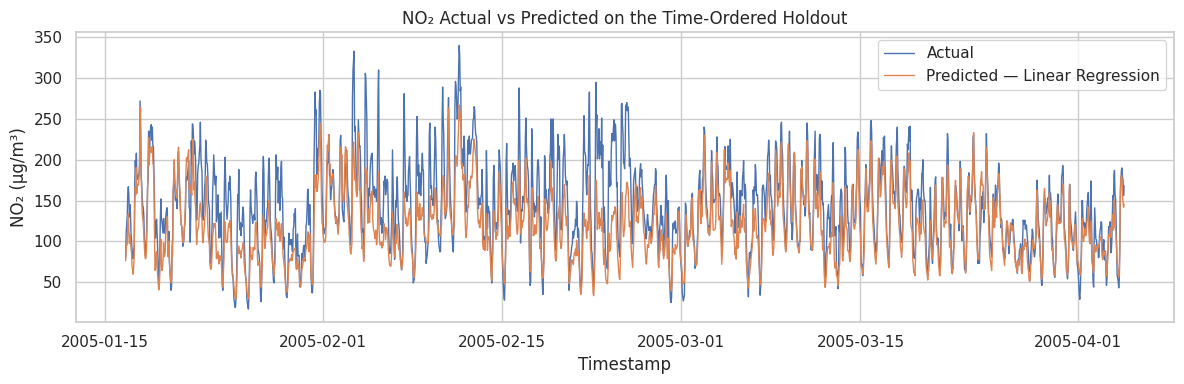

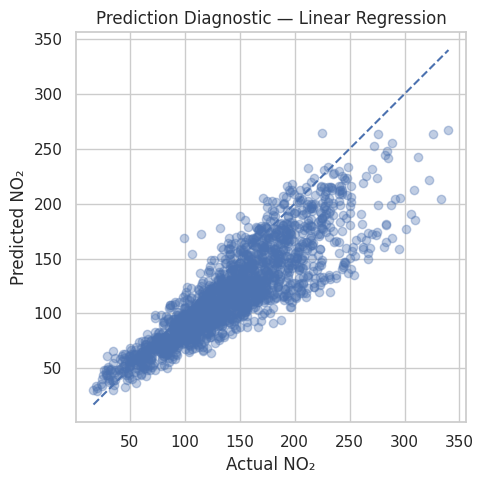

In [8]:
best_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_name]

plt.figure(figsize=(12,4))
plt.plot(test.index, y_test.values, label="Actual", linewidth=1)
plt.plot(test.index, best_pred, label=f"Predicted — {best_name}", linewidth=1)
plt.title("NO₂ Actual vs Predicted on the Time-Ordered Holdout")
plt.xlabel("Timestamp")
plt.ylabel("NO₂ (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_test, best_pred, alpha=0.35)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual NO₂")
plt.ylabel("Predicted NO₂")
plt.title(f"Prediction Diagnostic — {best_name}")
plt.tight_layout()
plt.show()


## 7. Explainability — what drives the model?

Permutation importance measures the change in predictive performance after shuffling one feature. It indicates model reliance, not causation.


,Feature,Importance,Std
4,PT08.S2(NMHC),16.3944,0.3091
3,C6H6(GT),12.9216,0.2585
5,NOx(GT),9.9529,0.3006
0,CO(GT),6.0322,0.2269
8,PT08.S5(O3),5.1777,0.2127
7,PT08.S4(NO2),1.2892,0.1146
11,AH,0.8132,0.0764
12,hour_sin,0.5540,0.0375
6,PT08.S3(NOx),0.4914,0.0355
16,day_of_week,0.1997,0.0304


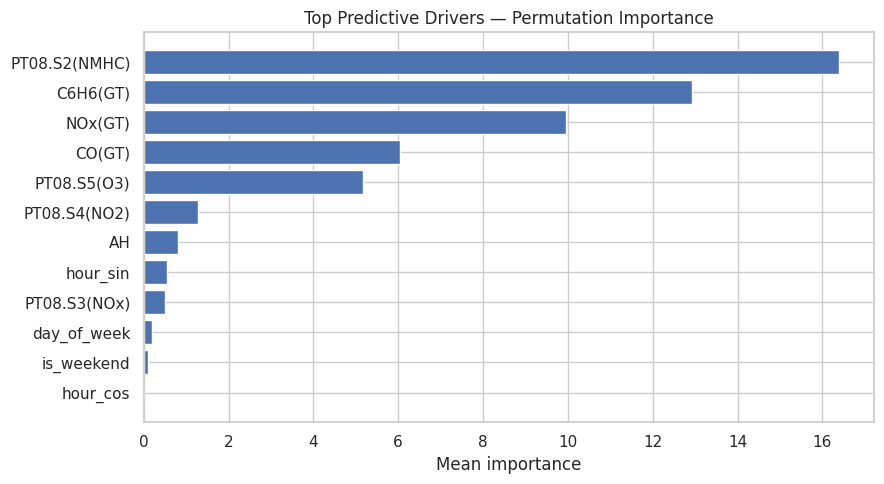

In [9]:
best_model = models[best_name]
perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=10,
    random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error"
)
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Importance", ascending=False).head(12)

display(importance_df.round(4))

plt.figure(figsize=(9,5))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.title("Top Predictive Drivers — Permutation Importance")
plt.xlabel("Mean importance")
plt.tight_layout()
plt.show()


## 8. Unsupervised AI — sensor anomaly detection

Isolation Forest flags unusual multivariate observations. An anomaly is a data-quality/analytical signal, not proof that the sensor is faulty.


In [10]:
anomaly_features = [c for c in features if c in df.columns]
iso_input = df[anomaly_features].copy()

iso = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", IsolationForest(
        n_estimators=200, contamination=0.03,
        random_state=RANDOM_STATE))
])
df["anomaly_flag"] = iso.fit_predict(iso_input)
df["anomaly_score"] = -iso.named_steps["model"].score_samples(
    iso.named_steps["scaler"].transform(
        iso.named_steps["imputer"].transform(iso_input)
    )
)

anomalies = (
    df[df["anomaly_flag"] == -1]
    .sort_values("anomaly_score", ascending=False)
    [["exposure_pressure_index", "NO2(GT)", "NOx(GT)", "CO(GT)", "T", "RH", "anomaly_score"]]
    .head(15)
)
display(anomalies.round(3))


,exposure_pressure_index,NO2(GT),NOx(GT),CO(GT),T,RH,anomaly_score
timestamp,,,,,,,
2004-10-26 18:00:00,97.756,180.0,952.0,9.5,22.5,61.5,0.667
2004-11-23 20:00:00,98.516,190.0,1358.0,11.5,11.5,76.2,0.664
2004-11-23 19:00:00,99.428,220.0,1389.0,11.9,12.4,74.7,0.663
2004-11-23 18:00:00,99.544,227.0,1369.0,10.2,13.2,72.6,0.661
2004-11-04 18:00:00,97.215,171.0,1014.0,8.7,23.1,61.1,0.658
2004-11-26 18:00:00,99.816,255.0,1389.0,10.1,15.5,62.8,0.655
2004-12-13 18:00:00,99.889,269.0,1479.0,9.9,12.6,55.9,0.655
2004-10-20 17:00:00,98.243,194.0,895.0,8.0,24.6,58.9,0.653
2004-10-25 18:00:00,94.602,149.0,860.0,8.4,21.0,64.9,0.652


## 9. AI analyst brief

This is a deterministic insight layer so the notebook remains reproducible without a paid LLM API. Its structured output can later be passed to IBM Granite or another approved LLM for natural-language summarization.


In [11]:
best_row = results_df.iloc[0]
peak_hour = int(hourly.idxmax())
peak_month = int(monthly.idxmax())
high_pressure_share = (df["exposure_pressure_index"] >= 75).mean() * 100
anomaly_share = (df["anomaly_flag"] == -1).mean() * 100

brief = f"""
AIRPULSE AI ANALYST BRIEF
-------------------------
- Peak average NO2 hour: {peak_hour:02d}:00
- Peak average NO2 month: {peak_month}
- High/very-high relative pressure observations: {high_pressure_share:.1f}%
- Detected multivariate anomalies: {anomaly_share:.1f}%
- Best holdout model by RMSE: {best_name}
- Best model MAE: {best_row["MAE"]:.2f}
- Best model RMSE: {best_row["RMSE"]:.2f}
- Best model R2: {best_row["R2"]:.3f}

INTERPRETATION
The analysis identifies recurring temporal variation and unusual multivariate
sensor observations. The predictive model provides a data-driven estimate of
NO2 under the observed conditions, while permutation importance highlights the
variables most useful to the model. These outputs are intended for analytical
decision support and are not medical or regulatory advice.
"""
print(brief)



AIRPULSE AI ANALYST BRIEF
-------------------------
- Peak average NO2 hour: 19:00
- Peak average NO2 month: 2
- High/very-high relative pressure observations: 20.6%
- Detected multivariate anomalies: 3.0%
- Best holdout model by RMSE: Linear Regression
- Best model MAE: 27.24
- Best model RMSE: 35.85
- Best model R2: 0.558

INTERPRETATION
The analysis identifies recurring temporal variation and unusual multivariate
sensor observations. The predictive model provides a data-driven estimate of
NO2 under the observed conditions, while permutation importance highlights the
variables most useful to the model. These outputs are intended for analytical
decision support and are not medical or regulatory advice.



## 10. Business and SDG-oriented recommendations

1. **Time-aware monitoring:** prioritize deeper inspection during recurring high-NO₂ periods.
2. **Sensor-quality monitoring:** review anomalous multivariate observations before operational use.
3. **Predictive analytics:** validate the selected model on newer/local data before deployment.
4. **Dashboard layer:** track average NO₂, pressure-band distribution, anomaly count, and model error.
5. **Responsible AI:** keep the relative pressure index separate from regulatory thresholds and validate deployment with domain experts.

**SDG alignment:** SDG 3 — Good Health and Well-Being; SDG 11 — Sustainable Cities and Communities.


## 11. Reproducibility checklist

- Python 3.10+ recommended
- Install dependencies from `requirements.txt`
- Run cells from top to bottom
- Internet access is required for the official UCI dataset download
- Results are generated dynamically from the dataset
- Dataset: UCI Machine Learning Repository — Air Quality
- DOI: 10.24432/C59K5F

**Compatibility note:** the notebook uses `np.sqrt(mean_squared_error(...))` for RMSE so it works across current scikit-learn versions where the older `squared=False` argument may not be available.
